# Why the saved velocity field isn't exactly divergence-free

**TL;DR.** The trajectories come from an *incompressible* Navier–Stokes solver, so the
underlying flow is divergence-free by construction ($\nabla\!\cdot\!\mathbf{u}=0$). The
saved field carries a small, *quantified* nonzero divergence for one reason only: to
shrink the $512^2$ simulation grid to the $64^2$ saved grid we use **bilinear**
down-sampling, and bilinear interpolation does not preserve incompressibility. It is a
property of the *save path*, not of the physics or the solver.

This notebook (1) states the diagnostic precisely, (2) measures it on the
Re $\in\{1000, 2000, 4000, 8000\}$ datasets, and (3) shows on a controlled example that
the alternative **spectral** down-sampler removes it down to machine precision —
matching what we saw on the spectral-downsampled run previously.

## 1. Why the field *should* be divergence-free

Incompressible flow obeys the continuity equation

$$\nabla\cdot\mathbf{u} \;=\; \partial_x u + \partial_y v \;=\; 0 .$$

Our data is generated by `NavierStokes2DSpectral`, a pseudo-spectral solver run in
**vorticity form**. Velocity is reconstructed from vorticity through the streamfunction
$\psi$ (`vorticity_to_velocity`):

$$\mathbf{u} = \nabla^{\perp}\psi = (\partial_y\psi,\,-\partial_x\psi),
\qquad \nabla^2\psi = -\,\omega .$$

A velocity built this way is divergence-free *identically*, because
$\nabla\cdot\nabla^{\perp}\psi = \partial_x\partial_y\psi - \partial_y\partial_x\psi = 0$.
Equivalently, in Fourier space

$$\widehat{\nabla\cdot\mathbf{u}}(\mathbf{k}) = i\,\mathbf{k}\cdot\hat{\mathbf{u}}(\mathbf{k}),$$

so being divergence-free means **the velocity of every mode is orthogonal to its
wavevector**, $\mathbf{k}\cdot\hat{\mathbf{u}}(\mathbf{k}) = 0$. On the simulation grid
this holds to spectral (≈ machine) precision; there is no physical compressibility in
this data.

## 2. The statistic we report

`dataset_viz.stats()` computes, at each saved time step and averaged over space **and**
the 16 samples, the root-mean-square divergence

$$\texttt{divergence\_rms}(t) \;=\; \sqrt{\big\langle (\nabla\cdot\mathbf{u})^2 \big\rangle_{x,\,\text{samples}}} .$$

Two design choices make this a *trustworthy* check rather than a numerical artifact of the
diagnostic itself:

- **The derivatives are spectral** (`divergence()` multiplies by $ik$ in Fourier space
  and inverse-transforms). On a periodic, band-limited field this is the *exact*
  derivative — so any nonzero value is a genuine property of the stored field, not a
  finite-difference truncation error.
- **It is reported dimensionlessly.** `summary()` gives the ratio
  $$\frac{\texttt{divergence\_rms}}{\omega_{\mathrm{rms}}},\qquad
  \omega_{\mathrm{rms}} = \sqrt{\langle\omega^2\rangle} = \sqrt{2\,\mathcal{E}_{\text{ens}}},$$
  because enstrophy is defined as $\mathcal{E}_{\text{ens}} = \tfrac12\langle\omega^2\rangle$.
  Divergence and vorticity are the two first-order invariants of the velocity-gradient
  tensor — its trace (dilatation) and its antisymmetric part (rotation) — so they share
  units ($1/\text{time}$) and their ratio is a clean "what fraction of the
  velocity-gradient scale is spurious dilatation."


## 3. Why the saved field isn't exactly divergence-free

The saved snapshots are **not** the full-resolution solver state. To keep files small,
each snapshot is down-sampled from the $512^2$ simulation grid to the $64^2$ saved grid
(`subsample = 8`), and the **default method is `bilinear`**
(`create_dataset._downsample_bilinear` → `F.interpolate(..., mode="bilinear")`).

Bilinear interpolation does not map a solenoidal field to a solenoidal one, for two
compounding reasons:

1. **Aliasing.** Sub-sampling below Nyquist folds sub-grid-scale modes back onto low
   wavenumbers. A mode that satisfied $\mathbf{k}\cdot\hat{\mathbf{u}}=0$ at its original
   $\mathbf{k}$ no longer satisfies it at the aliased $\mathbf{k}'$, so it injects
   divergence at the grid scale.
2. **Interpolation and differentiation don't commute.** The bilinear kernel is a local
   smoother, not an ideal low-pass; applied component-wise to $u$ and $v$ it breaks the
   exact cancellation that made the field divergence-free.

So the residual divergence is a small, controllable artifact of the (fast) bilinear save
path. The diagnostic exists precisely to *quantify* it.

## 4. Measured divergence across the Re sweep

Loading each split with `mmap` (lazy) and running the spectral diagnostic.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch, torch.fft as fft
import torch.nn.functional as F
import matplotlib.pyplot as plt
import dataset_viz as dv

DATA_ROOT = "/scratch/dwcgt/2dk_re_sweep"
SPLIT     = "test"                    # test/val ~1.4 GB each; train ~7.8 GB
RES       = [1000, 2000, 4000, 8000]  # the Re1k..8k sweep
paths = {re: f"{DATA_ROOT}/{SPLIT}/{SPLIT}_Re{re}.pt" for re in RES}
for re, p in paths.items():
    print(f"Re{re:<5} -> {p}")

Re1000  -> /scratch/dwcgt/2dk_re_sweep/test/test_Re1000.pt
Re2000  -> /scratch/dwcgt/2dk_re_sweep/test/test_Re2000.pt
Re4000  -> /scratch/dwcgt/2dk_re_sweep/test/test_Re4000.pt
Re8000  -> /scratch/dwcgt/2dk_re_sweep/test/test_Re8000.pt


In [2]:
# load + compute spectral diagnostics for each Re
results = {}
for re, p in paths.items():
    data = dv.load(p)
    s = dv.stats(data)
    results[re] = (data, s, dv.summary(data, s))

cols = ["Re", "saved grid", "mean KE", "mean enstrophy",
        "div_rms (med)", "div_rms (max)", "div/omega (med)"]
print(" | ".join(f"{c:>15}" for c in cols))
print("-" * (len(cols) * 18))
for re in RES:
    _, s, summ = results[re]
    ratio = np.median(s["divergence_rms"]) / np.sqrt(2 * np.median(s["enstrophy"]))
    row = [re, summ["saved grid"],
           f'{s["kinetic_energy"].mean():.4f}',
           f'{s["enstrophy"].mean():.3f}',
           f'{np.median(s["divergence_rms"]):.4f}',
           f'{s["divergence_rms"].max():.4f}',
           f'{ratio*100:.2f}%']
    print(" | ".join(f"{str(x):>15}" for x in row))

             Re |      saved grid |         mean KE |  mean enstrophy |   div_rms (med) |   div_rms (max) | div/omega (med)
------------------------------------------------------------------------------------------------------------------------------
           1000 |           64x64 |          1.0437 |           9.352 |          0.1627 |          0.2436 |           3.84%
           2000 |           64x64 |          1.1253 |          10.278 |          0.2530 |          0.4099 |           5.66%
           4000 |           64x64 |          1.1585 |          11.149 |          0.3449 |          0.5215 |           7.39%
           8000 |           64x64 |          1.1888 |          12.078 |          0.4118 |          0.6309 |           8.55%


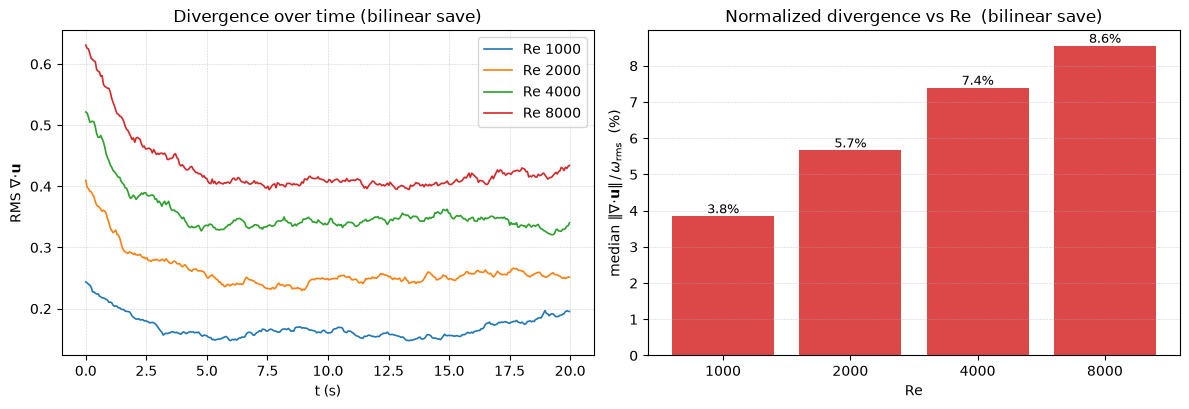

In [3]:
# left: RMS divergence over time per Re;  right: normalized divergence per Re
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for re in RES:
    _, s, _ = results[re]
    ax.plot(s["t"], s["divergence_rms"], lw=1.2, label=f"Re {re}")
ax.set_xlabel("t (s)"); ax.set_ylabel(r"RMS $\nabla\!\cdot\!\mathbf{u}$")
ax.set_title("Divergence over time (bilinear save)")
ax.grid(True, ls="--", lw=0.4, alpha=0.6); ax.legend()

ax = axes[1]
ratios = [100 * np.median(results[re][1]["divergence_rms"]) /
          np.sqrt(2 * np.median(results[re][1]["enstrophy"])) for re in RES]
bars = ax.bar([str(r) for r in RES], ratios, color="tab:red", alpha=0.85)
for b, v in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Re")
ax.set_ylabel(r"median $\|\nabla\!\cdot\!\mathbf{u}\|\,/\,\omega_{\mathrm{rms}}$  (%)")
ax.set_title("Normalized divergence vs Re  (bilinear save)")
ax.grid(True, axis="y", ls="--", lw=0.4, alpha=0.6)
fig.tight_layout()

## 5. The fix: spectral low-pass keeps the field divergence-free

`create_dataset` ships a second down-sampler, `spectral` (`_downsample_spectral`): an
ideal low-pass that truncates the velocity spectrum to the coarse grid's modes. Because
the integer wavenumbers are identical on both grids, a divergence-free spectrum
($\mathbf{k}\cdot\hat{\mathbf{u}}=0$) **stays** divergence-free after truncation — and the
Nyquist band is dropped on purpose so the conjugate-pair asymmetry can't reintroduce
grid-scale divergence.

We currently only have the **bilinear** datasets on disk. The cell below proves the
claim on a *controlled* example instead: take one analytically divergence-free field
(built from a random streamfunction on $512^2$) and down-sample it to $64^2$ **both
ways**, using the exact code path from `create_dataset`. Same field, same target grid —
the only difference is the down-sampler.

In [4]:
from create_dataset import _truncate_to_grid   # faithful spectral low-pass (mirrors _downsample_spectral)

torch.manual_seed(0)
n, ns = 512, 64                                  # simulation grid -> saved grid (subsample 8)
kr, kc = dv._kgrid(n, n, "cpu")                  # k_row (axis -2), k_col (axis -1)
psi_h = torch.randn(1, 1, n, n//2 + 1, dtype=torch.cfloat)
psi_h = psi_h * torch.exp(-(kr**2 + kc**2) / (2 * 10.0**2))   # band-limited streamfunction psi
u = fft.irfft2( 1j * kc * psi_h, s=(n, n))       # velocity from psi:
v = fft.irfft2(-1j * kr * psi_h, s=(n, n))       #   k_row*u_hat + k_col*v_hat = 0  =>  divergence-free

def div_over_vort(u_, v_):
    d, w = dv.divergence(u_, v_), dv.vorticity(u_, v_)
    return (d.pow(2).mean().sqrt() / w.pow(2).mean().sqrt()).item()

bil = F.interpolate(torch.cat([u, v], dim=1), size=(ns, ns), mode="bilinear")   # _downsample_bilinear
us, vs = _truncate_to_grid(fft.rfft2(u), ns), _truncate_to_grid(fft.rfft2(v), ns)  # _downsample_spectral

print(f"source field on {n}x{n}      div/omega = {div_over_vort(u, v):.2e}   (divergence-free)")
print(f"bilinear  {n} -> {ns}         div/omega = {div_over_vort(bil[:,0], bil[:,1]) * 100:6.2f} %")
print(f"spectral  {n} -> {ns}         div/omega = {div_over_vort(us, vs):.2e}   (stays divergence-free)")

source field on 512x512      div/omega = 1.91e-06   (divergence-free)
bilinear  512 -> 64         div/omega =   1.06 %
spectral  512 -> 64         div/omega = 2.01e-07   (stays divergence-free)


To regenerate the real spectral-downsampled dataset (per `scripts/README.md`):

```bash
../.venv/bin/python create_dataset.py --config-name 2dk_Re1k_test \
    downsample_method=spectral dataset_name=2dk_re_sweep_spectral_test
../.venv/bin/python aggregate_dataset.py /scratch/dwcgt/2dk_re_sweep_spectral_test
```

then point `DATA_ROOT`/`SPLIT` above at it and re-run section 4.

## 6. Better idea: down-sample the *vorticity*, then reconstruct velocity

Reconstructing velocity from a scalar vorticity through the streamfunction
($\mathbf{u}=\nabla^{\perp}\psi$, $\nabla^2\psi=-\omega$) gives

$$\nabla\cdot\mathbf{u} = \nabla\cdot\nabla^{\perp}\psi
= \partial_x\partial_y\psi - \partial_y\partial_x\psi \equiv 0$$

for *any* $\omega$ — it is the divergence of a curl. So the divergence-free guarantee lives
in the **reconstruction operator**, not in how $\omega$ was produced. If we down-sample the
vorticity (by any method) and then rebuild velocity on the coarse grid, the saved field is
divergence-free to machine precision — **even with bilinear** down-sampling.

In Fourier (the module's convention), $\nabla^2\psi=-\omega$ is
$\hat\psi = \hat\omega/|\mathbf{k}|^2$, then $\hat u = i k_{\text{col}}\hat\psi$,
$\hat v = -i k_{\text{row}}\hat\psi$ — which satisfies
$k_{\text{row}}\hat u + k_{\text{col}}\hat v = 0$ identically.

In [5]:
def velocity_from_vorticity(omega):
    # Velocity from a scalar vorticity via the streamfunction (dv's k convention).
    # div(u) is the divergence of a curl == 0 *identically* for ANY omega -- so the
    # reconstruction is what guarantees incompressibility, not the down-sampler.
    h, w = omega.shape[-2:]
    kr_, kc_ = dv._kgrid(h, w, omega.device)
    oh = fft.rfft2(omega)
    k2 = (kr_**2 + kc_**2).clone(); k2[..., 0, 0] = 1.0     # avoid 0/0 at the mean mode
    psi = oh / k2; psi[..., 0, 0] = 0.0
    return fft.irfft2(1j * kc_ * psi, s=(h, w)), fft.irfft2(-1j * kr_ * psi, s=(h, w))

# a deliberately broadband vorticity field (energy reaching the coarse Nyquist), i.e. an
# under-resolved / high-Re-like snapshot -- this is what makes the artifacts large & visible
torch.manual_seed(0)
kr, kc = dv._kgrid(n, n, "cpu"); kmag = torch.sqrt(kr**2 + kc**2)
om_hat = (kmag + 1.0) ** (-0.5) * torch.exp(2j * np.pi * torch.rand(1, 1, n, n//2 + 1))
om_hat[..., 0, 0] = 0
omega_f = fft.irfft2(om_hat, s=(n, n)); omega_f = omega_f / omega_f.std()
u_f, v_f = velocity_from_vorticity(omega_f)            # fine, divergence-free reference

bil = F.interpolate(torch.cat([u_f, v_f], 1), size=(ns, ns), mode="bilinear")
methods = [
    ("velocity bilinear   (current default)",      bil[:, 0], bil[:, 1]),
    ("velocity spectral   (_downsample_spectral)", *(_truncate_to_grid(fft.rfft2(u_f), ns),
                                                     _truncate_to_grid(fft.rfft2(v_f), ns))),
    ("vorticity bilinear  -> reconstruct",         *velocity_from_vorticity(
                                                     F.interpolate(omega_f, size=(ns, ns), mode="bilinear"))),
    ("vorticity spectral  -> reconstruct",         *velocity_from_vorticity(
                                                     _truncate_to_grid(fft.rfft2(omega_f), ns))),
]
coarse = {name: (uu, vv) for name, uu, vv in methods}
print(f"fine {n}x{n} velocity            div/omega = {div_over_vort(u_f, v_f):.2e}\n")
print(f"{'down-sample path':42s} {'div/omega':>11s}")
print("-" * 56)
for name, uu, vv in methods:
    print(f"{name:42s} {div_over_vort(uu, vv):11.2e}")

fine 512x512 velocity            div/omega = 1.44e-06

down-sample path                             div/omega
--------------------------------------------------------
velocity bilinear   (current default)         4.43e-01
velocity spectral   (_downsample_spectral)    4.43e-07
vorticity bilinear  -> reconstruct            2.70e-07
vorticity spectral  -> reconstruct            4.35e-07


**So yes — your idea works.** Both `vorticity -> reconstruct` rows sit at machine
precision, exactly like the spectral-velocity path, while down-sampling velocity
*bilinearly* leaves a large divergence on this broadband field. The two properties are on
**independent axes**:

- **Divergence-free** is bought by reconstructing velocity from vorticity — unconditionally,
  for any down-sampler.
- **Alias-free / spectral fidelity** is a *separate* choice of how the vorticity itself is
  down-sampled (bilinear vs spectral) — the subject of section 7.

## 7. Aliasing vs. Gibbs — and what matters for PDE-Refiner across the Re sweep

Once incompressibility is handled, the down-sampler choice is only about how it treats the
energy the coarse grid cannot represent (here, $k>32$):

| | bilinear | spectral (sharp cut) |
|---|---|---|
| sub-grid energy | **aliased** — folds onto resolved $k$ at the *wrong* wavenumber | **discarded** cleanly; retained modes exact |
| real space | local, convex → **no overshoot**, stays bounded | brick-wall in Fourier = sinc in space → **Gibbs ringing** at sharp gradients |
| spectrum | corrupted near Nyquist | exact below the cut, zero above |

The next two cells make each artifact visible on the field from section 6.

near Nyquist (k=32): bilinear holds 2.92x the exact energy


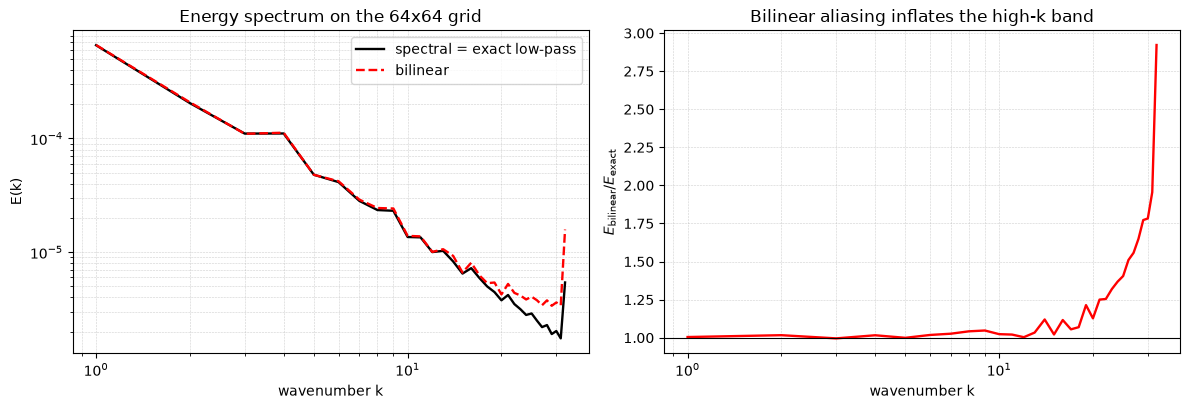

In [6]:
# ALIASING: energy spectrum of the two velocity down-samples.
# The spectral one IS the exact band-limited reference (fine spectrum truncated to k<=ns/2).
ub, vb = coarse["velocity bilinear   (current default)"]
us2, vs2 = coarse["velocity spectral   (_downsample_spectral)"]
kk, E_bil = dv.energy_spectrum(ub, vb)
_,  E_spc = dv.energy_spectrum(us2, vs2)
m = (kk >= 1) & (E_spc > 0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].loglog(kk[m], E_spc[m], "k-",  lw=1.7, label="spectral = exact low-pass")
ax[0].loglog(kk[m], E_bil[m], "r--", lw=1.7, label="bilinear")
ax[0].set_xlabel("wavenumber k"); ax[0].set_ylabel("E(k)")
ax[0].set_title("Energy spectrum on the 64x64 grid")
ax[0].legend(); ax[0].grid(True, which="both", ls="--", lw=0.4, alpha=0.6)
ax[1].semilogx(kk[m], E_bil[m] / E_spc[m], "r-", lw=1.7); ax[1].axhline(1.0, color="k", lw=0.8)
ax[1].set_xlabel("wavenumber k"); ax[1].set_ylabel(r"$E_{\rm bilinear}/E_{\rm exact}$")
ax[1].set_title("Bilinear aliasing inflates the high-k band")
ax[1].grid(True, which="both", ls="--", lw=0.4, alpha=0.6)
fig.tight_layout()
print(f"near Nyquist (k={int(kk[m][-1])}): bilinear holds {(E_bil/E_spc)[int(kk[m][-1])]:.2f}x the exact energy")

spectral 64: range [-0.080, 1.111] (true [0,1]) -> 11% overshoot, 8% undershoot
bilinear 64: range [0.000, 1.000] (no overshoot -- convex)


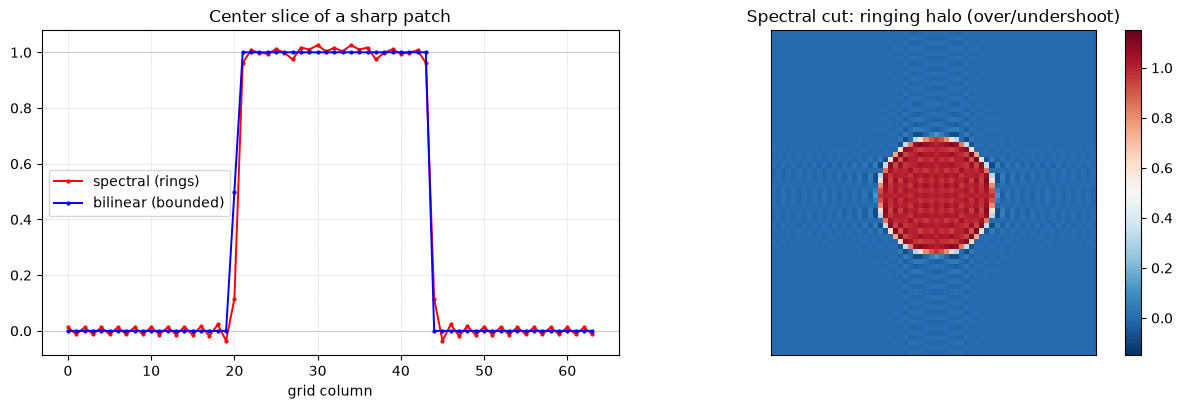

In [7]:
# GIBBS: a sharp-edged vorticity patch (true values in {0,1}); sharp cut rings, bilinear does not
yy, xx = torch.meshgrid(torch.arange(n), torch.arange(n), indexing="ij")
disk = (((xx - n/2)**2 + (yy - n/2)**2) < (n * 0.18)**2).float()[None, None]
disk_spc = _truncate_to_grid(fft.rfft2(disk), ns)
disk_bil = F.interpolate(disk, size=(ns, ns), mode="bilinear")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
mid = ns // 2
ax[0].axhline(1, color="0.8", lw=0.8); ax[0].axhline(0, color="0.8", lw=0.8)
ax[0].plot(disk_spc[0, 0, mid].numpy(), "r.-", lw=1.4, ms=4, label="spectral (rings)")
ax[0].plot(disk_bil[0, 0, mid].numpy(), "b.-", lw=1.4, ms=4, label="bilinear (bounded)")
ax[0].set_title("Center slice of a sharp patch"); ax[0].set_xlabel("grid column")
ax[0].legend(); ax[0].grid(True, ls="--", lw=0.4, alpha=0.6)
im = ax[1].imshow(disk_spc[0, 0].numpy(), cmap="RdBu_r", vmin=-0.15, vmax=1.15)
ax[1].set_title("Spectral cut: ringing halo (over/undershoot)")
ax[1].set_xticks([]); ax[1].set_yticks([]); fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout()
print(f"spectral 64: range [{disk_spc.min():.3f}, {disk_spc.max():.3f}] (true [0,1])"
      f" -> {100*(disk_spc.max()-1):.0f}% overshoot, {-100*disk_spc.min():.0f}% undershoot")
print(f"bilinear 64: range [{disk_bil.min():.3f}, {disk_bil.max():.3f}] (no overshoot -- convex)")

### What this means for our setting

**The model — PDE-Refiner.** PDE-Refiner (Lippe et al., 2023) is built to model the
*entire* energy spectrum, including the low-amplitude high-wavenumber modes that an
MSE-trained surrogate neglects but that govern long-rollout stability. Its whole value
proposition is spectral fidelity. That makes **aliasing the more dangerous artifact**:
bilinear inflates the high-$k$ band (right panel above — up to ~2x the true energy near
Nyquist) with energy folded down from unresolved scales. We would be training a
spectrum-faithful model to reproduce a *spectrum that isn't the PDE's*, in exactly the band
it cares most about. A sharp spectral cut instead hands it the exact band-limited
projection (a Galerkin / LES sharp filter): every retained mode is correct, nothing folds.

**Gibbs is a genuine real-space cost — not a free lunch.** PDE-Refiner is trained with a
*real-space* objective (a diffusion-style MSE on the discretized field); its spectral
behaviour is the *motivation*, but the loss sees grid values. So the sharp-cut ringing
(~9-11% over/undershoot near thin filaments, with spurious sign flips) is part of the
training target: the model will fit it, spend loss budget on it, and it counts as error
against unfiltered DNS in any pointwise metric.

The real asymmetry is therefore *what kind* of error each filter makes, not "spectral vs.
real space":

- **bilinear** gets the resolved modes themselves *wrong* — it attenuates mid-$k$ and folds
  unresolved energy back onto resolved $k$ (aliasing), so the high-$k$ content PDE-Refiner
  exists to capture is corrupted at the source;
- **sharp-spectral** gets every resolved mode *exactly right* and zero above the cut (the
  L2-optimal band-limited projection — the modes' values are correct), at the price of
  localized real-space ringing.

For a spectrum-faithful model a *wrong* high-$k$ spectrum (aliasing) is the more damaging of
the two — but because the ringing is genuinely in the real-space target, the clean answer is
a **smooth** spectral filter (next).

(Aside: the closure problem is filter-independent — at $64^2$ neither filter yields a
*closed* coarse dynamics, since the next-step target always depends on unresolved scales.
This is about the fidelity of the representation, not about making the coarse map well-posed.)

**The Reynolds sweep sharpens the choice.** Higher Re pushes the enstrophy cascade toward
the grid Nyquist, so more energy sits at the scales the down-sampler mistreats. Section 4
already shows this: median $\|\nabla\!\cdot\!\mathbf u\|/\omega_{\rm rms}$ climbs
$3.8\%\to8.6\%$ from Re1k to Re8k — a direct proxy for "how much energy is piled at the grid
scale." Both artifacts are therefore worst for the high-Re cases, which are exactly the ones
that stress a refiner's spectrum.

**Recommendation.** Reconstruct velocity from down-sampled vorticity (free
incompressibility), and prefer a **spectral** low-pass for spectral fidelity. If filament
ringing proves harmful, a *smooth* spectral filter (exponential / Gaussian roll-off, or 2/3
de-aliasing) trades a slightly softer cutoff for much less Gibbs — the classic LES
sharp-vs-smooth filter trade-off. The most robust fix to both is resolution: simulate/save
fine enough that little energy reaches Nyquist in the first place.

---
## Summary for the advisor

1. **The data is incompressible by construction.** The solver enforces
   $\nabla\cdot\mathbf{u}=0$; the spectral save path preserves it to machine precision (§5).
2. **The few-percent divergence in the shipped (bilinear) datasets is a measured
   down-sampling artifact**, concentrated at the $64^2$ grid scale and growing with Re
   ($3.8\%\to8.6\%$, §4) — not a physics or solver error.
3. **Down-sampling vorticity and reconstructing velocity removes it for free** — even with
   bilinear — because incompressibility comes from the reconstruction, not the filter (§6).
4. **Filter choice is a separate, spectral question** (§7): bilinear aliases (corrupts
   high-$k$), sharp-spectral rings (Gibbs). For a spectrum-faithful model like PDE-Refiner
   over a Reynolds sweep, aliasing is the worse sin — so we recommend a spectral (optionally
   smooth) low-pass, and ultimately enough resolution to resolve the cascade before
   Nyquist.